# Baseline Model
1. Train a Linear Regression as the first model. 
2. Evaluate using R² on the test set. 
3. Record baseline results. 

This notebook was done after removing outliers from the training set.

### 1. Linear Regression Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

X_train = pd.read_csv('X_train.csv')
X_val = pd.read_csv('X_val.csv')
X_test = pd.read_csv('X_test.csv')

Y_train = np.load('Y_train.npy')
Y_val = np.load('Y_val.npy')
Y_test = np.load('Y_test.npy')

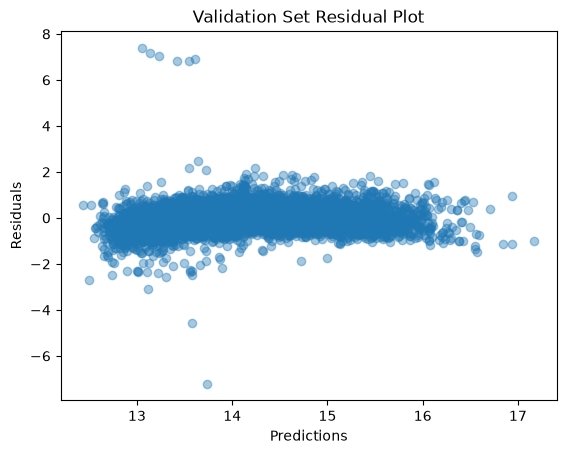

In [2]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, np.log1p(Y_train))

predictions_val = lr.predict(X_val)
residuals = np.log1p(Y_val) - predictions_val

plt.scatter(predictions_val, residuals, alpha=0.4)
plt.title('Validation Set Residual Plot')
plt.xlabel('Predictions')
plt.ylabel('Residuals');

In [3]:
X_val[residuals > 4]

,Latitude,Longitude,City,PostalCode,MLSAreaMajor,HighSchoolDistrict,LivingArea,BedroomsTotal,BathroomsTotalInteger,YearBuilt,...,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba,ViewYN_True,ViewYN_Unknown,PoolPrivateYN_True,PoolPrivateYN_Unknown,AttachedGarageYN_True,AttachedGarageYN_Unknown
1583,33.022839,-116.804242,9.187730e+05,9.187730e+05,9.187730e+05,8.851599e+05,7.656810,3.0,2.0,1984.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5247,33.675959,-117.290553,6.086874e+05,6.460811e+05,6.574367e+05,6.654765e+05,7.633370,4.0,3.0,1997.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17017,32.625679,-117.065524,1.005990e+06,8.331030e+05,8.331030e+05,9.768493e+05,7.597396,4.0,3.0,1959.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26394,33.185572,-117.302394,9.724608e+05,9.349387e+05,9.366644e+05,9.214333e+05,7.007601,2.0,1.0,1972.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29606,32.572879,-117.062559,1.369208e+06,8.203594e+05,8.217871e+05,9.768493e+05,7.275865,4.0,2.0,1978.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30036,33.250628,-117.135871,1.034167e+06,1.035977e+06,1.034167e+06,1.021297e+06,7.568896,2.0,3.0,1977.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
pd.DataFrame(Y_val).sort_values(by=0, ascending=False).head(6)

,0
30036,796000000.0
29606,768500000.0
1583,699000000.0
17017,664250000.0
26394,645000000.0
5247,615000000.0


Our model is underestimating the six highest-value properties.

### 2. R² Evaluation

In [5]:
print('Training score: ', lr.score(X_train, np.log1p(Y_train)))
print('Validation score: ', lr.score(X_val, np.log1p(Y_val)))
print('Test score: ', lr.score(X_test, np.log1p(Y_test)))

Training score:  0.8127073597724899
Validation score:  0.7910362228742552
Test score:  0.7997505148813567


##### K-Fold Cross Validation

Combine training and validation datasets to remove outliers.

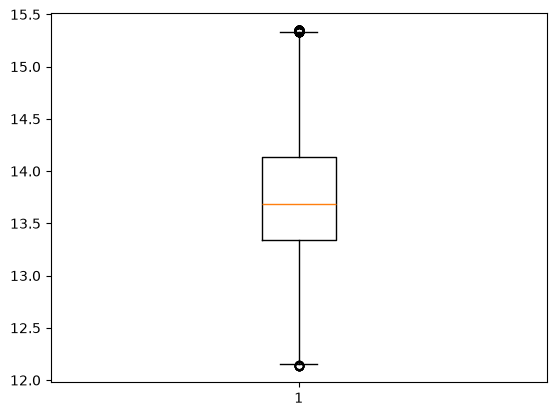

In [6]:
X_train_val = pd.concat([X_train, X_val], axis=0)
Y_train_val = pd.concat([pd.DataFrame(Y_train), pd.DataFrame(Y_val)], axis=0).rename(columns={0: 'ClosePrice'})
train_val_df = pd.concat([X_train_val, Y_train_val], axis=1)

Q1 = np.log1p(train_val_df['ClosePrice']).quantile(0.25)
Q3 = np.log1p(train_val_df['ClosePrice']).quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

is_outlier = (np.log1p(train_val_df['ClosePrice']) <= lower_bound) | (np.log1p(train_val_df['ClosePrice']) >= upper_bound)

train_val_df = train_val_df[~is_outlier]
plt.boxplot(np.log1p(train_val_df['ClosePrice']));

X_train_val = train_val_df.drop(['ClosePrice'], axis=1)
Y_train_val = train_val_df[['ClosePrice']]

In [7]:
from sklearn.model_selection import KFold, cross_val_score

lr_kfold = LinearRegression()

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(lr_kfold, X_train_val, Y_train_val, cv=kf)

for i in range(len(scores)):
    print(f'Fold {i+1} Score: {scores[i]}')

Fold 1 Score: 0.7762613421633844
Fold 2 Score: 0.7833203815585567
Fold 3 Score: 0.780392836648219
Fold 4 Score: 0.7853247212262702
Fold 5 Score: 0.7800330286521331


### 3. Baseline Results

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, r2_score

# always predict the mean
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, np.log1p(Y_train))
dummy_val_preds = dummy.predict(X_val)

print("Dummy baseline R²:", r2_score(np.log1p(Y_val), dummy_val_preds))
print("Dummy baseline RMSE:", np.sqrt(mean_squared_error(np.log1p(Y_val), dummy_val_preds)))

Dummy baseline R²: -0.004210840161302354
Dummy baseline RMSE: 0.4768769364651933


In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# predictions are on the log scale

predictions_train = lr.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(np.log1p(Y_train), predictions_train))
mae_train = mean_absolute_error(np.log1p(Y_train), predictions_train)
r2_train = lr.score(X_train, np.log1p(Y_train))

predictions_test = lr.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(np.log1p(Y_test), predictions_test))
mae_test = mean_absolute_error(np.log1p(Y_test), predictions_test)
r2_test = lr.score(X_test, np.log1p(Y_test))

print(f'Train Metrics: RMSE: {rmse_train}, MAE: {mae_train}, R2: {r2_train}')
print(f'Test Metrics: RMSE: {rmse_test}, MAE: {mae_test}, R2: {r2_test}')

Train Metrics: RMSE: 0.25619090314607323, MAE: 0.19208242281357643, R2: 0.8127073597724899
Test Metrics: RMSE: 0.3060447119869228, MAE: 0.21364284900625224, R2: 0.7997505148813567


**Results: Our baseline Linear Regression model produces a test score of about 0.80, which is significant compared to a baseline model that only predicts the mean. Outliers and large property prices in our dataset tend to negatively affect this model, as seen in our residual plot. These values are underestimated.**